# L11 · 1D CNNs and RNNs for Regulatory DNA

*Companion notebook for Lecture 11 — Sequence Models: 1D CNNs and RNNs (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Encode DNA as a one-hot matrix $\mathbf X\in\{0,1\}^{L\times 4}$ and simulate sequences with real JASPAR motifs.
2. Verify numerically that scoring with a PWM (Lecture 3) **is** a 1D convolution with filter $\mathbf K = \log(\boldsymbol\Theta/q)$.
3. Train a 1D CNN to detect a CTCF site and read its learned filter as a sequence logo.
4. Show that a globally pooled CNN cannot learn motif **order and spacing**, while a CNN + BiLSTM (DanQ-style) can; explain its predictions with saliency maps.
5. Measure vanishing gradients in a plain RNN versus an LSTM.

Runtime: about 2 minutes on a laptop CPU (4 threads); no GPU needed.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mp
import torch
from torch import nn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from course_utils import (seed_everything, plot_style, load_jaspar, pwm_from_counts, plot_logo, sample_from_pwm,
                          random_dna, BASES, BASE_COLORS, PALETTE)

rng = seed_everything(0)
plot_style()
torch.set_num_threads(min(4, torch.get_num_threads()))   # small models: more threads do not help

SEQ_L = 200                              # sequence length L (bp)
N1 = (4000, 1000, 2000)                  # task 1 train / val / test
N2 = (8000, 2000, 2000)                  # task 2 train / val / test
EP1, EP2 = 10, 15                        # epochs for task 1 and task 2
GAP_NEAR, GAP_FAR = (10, 50), (90, 150)  # task 2 gaps (bp between the two sites; upper bound exclusive)

# --- knobs for "Try it yourself" (defaults reproduce the lecture) ---
GC = 0.5              # GC content of the random background (try 0.6)
BOTH_STRANDS = False  # task 1: plant each CTCF site on a random strand (forward or reverse complement)
RC_AUG = False        # task 1: add the reverse complement of every training sequence
RNN_CELL = "LSTM"     # task 2 hybrid model: "LSTM" or "GRU"

IDX = {b: i for i, b in enumerate(BASES)}
COL_A, COL_B = PALETTE[0], PALETTE[5]

## 1. Dataset: transcription-factor sites in simulated regulatory DNA

**Biological context.** Transcription factors (TFs) are proteins that bind short DNA words (6–20 bp) in promoters and enhancers and switch genes on or off. Experiments such as **ChIP-seq** (which DNA is bound by a given TF in a cell type) and **ATAC-seq / DNase-seq** (which DNA is open) give genome-wide labels; a sequence model learns to predict them from the DNA alone, and can then score the effect of a non-coding variant.

- **CTCF** (JASPAR **MA0139.1**, 19 bp, GC-rich): the insulator protein that anchors chromatin loops.
- **FOXA1** (JASPAR **MA0148.4**, 12 bp, AT-rich): a forkhead "pioneer" factor that opens chromatin in liver, breast and prostate.

**What one sample is.** One 200-bp DNA sequence, $\mathbf s = (s_1,\dots,s_L)$, encoded as $\mathbf X\in\{0,1\}^{200\times 4}$ (columns A, C, G, T). The sequences are **simulated** — random background bases with binding sites *sampled* from the real JASPAR matrices (so each site is a degenerate variant, like real sites) — so the ground truth is known.

- **Task 1 (motif presence).** $y=1$ if the sequence contains a CTCF site (half do), at a random position. Half of all sequences also contain a FOXA1 site as a distractor. 4,000 / 1,000 / 2,000 train / validation / test.
- **Task 2 (motif grammar).** *Every* sequence contains one CTCF site (A) and one FOXA1 site (B). $y=1$ iff **A is upstream of B with a gap of 10–49 bp**. Negatives: B upstream of A (same gaps), or A upstream of B but far apart (90–149 bp). 8,000 / 2,000 / 2,000. The rule is a teaching toy; real enhancer grammars are softer.

**Why it matters.** Most disease-associated variants lie in non-coding DNA; models such as DeepBind, DeepSEA and DanQ predict how sequence changes alter TF binding.

**Source.** Position frequency matrices from **JASPAR 2024** (Rauluseviciute et al., *Nucleic Acids Res.* 52, D174, 2024; open data, CC BY 4.0), fetched once from the JASPAR REST API and cached in `applications/data/`. Everything else is simulated here.

motif A: CTCF MA0139.1, W = 19;  motif B: FOXA1 MA0148.4, W = 12


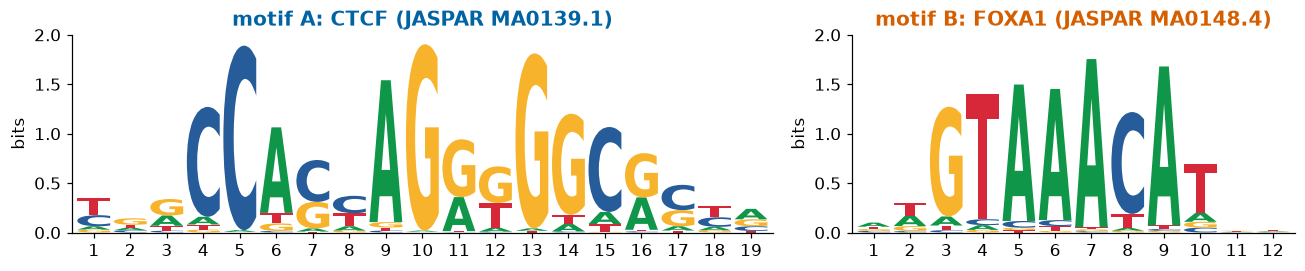

In [2]:
nameA, cntA = load_jaspar("MA0139.1")
nameB, cntB = load_jaspar("MA0148.4")
thA, thB = pwm_from_counts(cntA), pwm_from_counts(cntB)     # Θ (W x 4), pseudocount 0.5
WA, WB = len(thA), len(thB)
print(f"motif A: {nameA} MA0139.1, W = {WA};  motif B: {nameB} MA0148.4, W = {WB}")

fig, axs = plt.subplots(1, 2, figsize=(12, 2.6), gridspec_kw=dict(width_ratios=[WA, WB]))
plot_logo(axs[0], thA); axs[0].set_title(f"motif A: {nameA} (JASPAR MA0139.1)", color=COL_A)
plot_logo(axs[1], thB); axs[1].set_title(f"motif B: {nameB} (JASPAR MA0148.4)", color=COL_B)
plt.tight_layout(); plt.show()

The simulators below are ported from the lecture file. `_plant` overwrites the background with a site; for task 1 the optional `BOTH_STRANDS` knob plants the reverse complement of the site half of the time.

In [3]:
COMP = {"A": "T", "C": "G", "G": "C", "T": "A"}
revcomp = lambda s: "".join(COMP[c] for c in reversed(s))

def onehot(seqs):
    a = np.array([[IDX[c] for c in s] for s in seqs])
    return np.eye(4, dtype=np.float32)[a]          # n x L x 4

def _plant(s, site, p):
    return s[:p] + site + s[p + len(site):]

def task1_data(rng, n, gc=GC, both_strands=BOTH_STRANDS):
    """Half the sequences contain one CTCF site (y = 1) at a random position; half of all sequences also
    contain a FOXA1 site as a distractor."""
    seqs = random_dna(rng, n, SEQ_L, gc)
    y = (rng.random(n) < 0.5).astype(int)
    A, B = sample_from_pwm(thA, rng, n), sample_from_pwm(thB, rng, n)
    out, posA = [], np.full(n, -1)
    for i, s in enumerate(seqs):
        if rng.random() < 0.5:
            s = _plant(s, B[i], int(rng.integers(0, SEQ_L - WB + 1)))
        if y[i]:
            posA[i] = int(rng.integers(0, SEQ_L - WA + 1))
            site = revcomp(A[i]) if both_strands and rng.random() < 0.5 else A[i]
            s = _plant(s, site, posA[i])
        out.append(s)
    return out, y, posA

def task2_data(rng, n, gc=GC):
    """Every sequence has one CTCF site (A) and one FOXA1 site (B).
    kind 0 (y = 1): A upstream of B, gap in GAP_NEAR.  kind 1: B upstream of A, same gaps.
    kind 2: A upstream of B but far apart (gap in GAP_FAR).  Kinds 1 and 2 are negatives."""
    seqs = random_dna(rng, n, SEQ_L, gc)
    A, B = sample_from_pwm(thA, rng, n), sample_from_pwm(thB, rng, n)
    kind = rng.choice(3, n, p=[0.5, 0.25, 0.25])
    out, pos = [], []
    for i in range(n):
        g = int(rng.integers(*(GAP_FAR if kind[i] == 2 else GAP_NEAR)))
        st = int(rng.integers(0, SEQ_L - (WA + WB + g) + 1))
        if kind[i] == 1:
            pb, pa = st, st + WB + g
        else:
            pa, pb = st, st + WA + g
        out.append(_plant(_plant(seqs[i], A[i], pa), B[i], pb))
        pos.append((pa, pb))
    return out, (kind == 0).astype(int), kind, np.array(pos)

# same random stream as the lecture: task 1 first, then task 2, both from seed 0
s1, y1, posA1 = task1_data(rng, sum(N1))
s2, y2, kind2, pos2 = task2_data(rng, sum(N2))
print(f"task 1: {len(s1):,} sequences, {y1.mean():.1%} positives")
print(f"task 2: {len(s2):,} sequences, {y2.mean():.1%} positives; kinds (A→B near, B→A, A→B far):",
      np.bincount(kind2))

task 1: 7,000 sequences, 49.5% positives
task 2: 12,000 sequences, 50.2% positives; kinds (A→B near, B→A, A→B far): [6020 3028 2952]


## 2. Exploration

One-hot encoding: each row is a position, each column a base; the four bases are the **input channels** of a 1D convolution.

In [4]:
X_demo = onehot(["GATTACACGT"])[0]
print("GATTACACGT ->  columns", list(BASES))
print(X_demo.astype(int))

sA = "".join(BASES[i] for i in thA.argmax(1))
print(f"\nCTCF consensus: {sA}   GC content of the consensus: {np.mean([c in 'GC' for c in sA]):.0%}")
print("an example planted CTCF site (task 1, first positive):",
      s1[int(np.argmax(y1))][posA1[int(np.argmax(y1))]:posA1[int(np.argmax(y1))] + WA])
gc_bg = np.mean([np.mean([c in "GC" for c in s]) for s in s1[:500]])
print(f"background GC content (first 500 task-1 sequences): {gc_bg:.3f}")

GATTACACGT ->  columns ['A', 'C', 'G', 'T']
[[0 0 1 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]

CTCF consensus: TGGCCACCAGGGGGCGCTA   GC content of the consensus: 74%
an example planted CTCF site (task 1, first positive): CAACCAGCAGGGGAAATCG
background GC content (first 500 task-1 sequences): 0.503


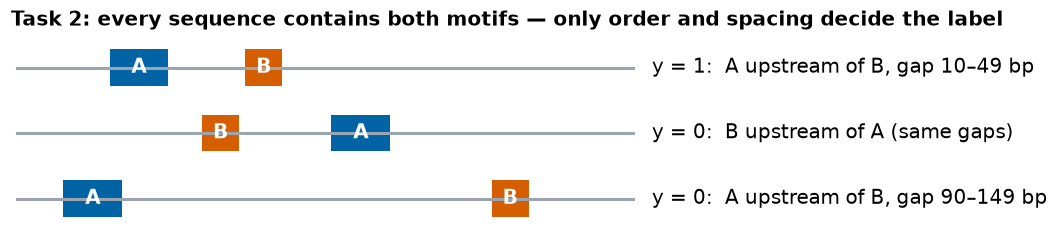

In [5]:
fig, ax = plt.subplots(figsize=(12, 2.4))
rows = [("y = 1:  A upstream of B, gap 10–49 bp", [("A", 30, WA), ("B", 30 + WA + 25, WB)]),
        ("y = 0:  B upstream of A (same gaps)", [("B", 60, WB), ("A", 60 + WB + 30, WA)]),
        ("y = 0:  A upstream of B, gap 90–149 bp", [("A", 15, WA), ("B", 15 + WA + 120, WB)])]
for r, (lab, sites) in enumerate(rows):
    yy = 2 - r
    ax.plot([0, SEQ_L], [yy, yy], color="#9AA5B1", lw=2)
    for name, p, w in sites:
        ax.add_patch(mp.Rectangle((p, yy - 0.28), w, 0.56, fc=COL_A if name == "A" else COL_B, ec="none"))
        ax.text(p + w / 2, yy, name, ha="center", va="center", color="white", fontsize=13, weight="bold")
    ax.text(SEQ_L + 6, yy, lab, va="center", fontsize=13)
ax.set_xlim(-2, 330); ax.set_ylim(-0.6, 2.5); ax.axis("off")
ax.set_title("Task 2: every sequence contains both motifs — only order and spacing decide the label", loc="left")
plt.show()

## 3. Preprocessing: one-hot DNA, and a PWM score is a convolution

The L03 log-odds score of the window starting at $t$ is
$$S_t=\sum_{w=1}^{W}\log\frac{\theta_{w,s_{t+w-1}}}{q_{s_{t+w-1}}}=\sum_{w=1}^{W}\sum_a K_{w,a}\,X_{t+w-1,a},\qquad K_{w,a}=\log\frac{\theta_{w,a}}{q_a}.$$
Multiplying by a one-hot row picks one entry of $\mathbf K$, so the PWM scanner is exactly `conv1d` with a fixed $4$-channel kernel of width $W$. First the lecture's worked example (3-bp motif, sequence `TACTGAC`), then CTCF on 1,000 random sequences.

In [6]:
TOY_THETA = np.array([[0.7, 0.1, 0.1, 0.1], [0.1, 0.7, 0.1, 0.1], [0.1, 0.1, 0.1, 0.7]])
TOY_SEQ = "TACTGAC"
Ktoy = np.log(TOY_THETA / 0.25)                                       # W x 4
conv = nn.functional.conv1d(torch.tensor(onehot([TOY_SEQ])[0].T[None]), torch.tensor(Ktoy.T[None], dtype=torch.float32))
loop = [sum(np.log(TOY_THETA[w, IDX[TOY_SEQ[t + w]]] / 0.25) for w in range(3)) for t in range(len(TOY_SEQ) - 2)]
print("filter K = log(θ/q)   (rows w = 1..3, columns A C G T)\n", Ktoy.round(2))
for t, (c, l) in enumerate(zip(conv[0, 0].numpy(), loop)):
    print(f"t = {t + 1}  window {TOY_SEQ[t:t + 3]}  conv1d {c:+.2f}  loop {l:+.2f}")

filter K = log(θ/q)   (rows w = 1..3, columns A C G T)
 [[ 1.03 -0.92 -0.92 -0.92]
 [-0.92  1.03 -0.92 -0.92]
 [-0.92 -0.92 -0.92  1.03]]
t = 1  window TAC  conv1d -2.75  loop -2.75
t = 2  window ACT  conv1d +3.09  loop +3.09
t = 3  window CTG  conv1d -2.75  loop -2.75
t = 4  window TGA  conv1d -2.75  loop -2.75
t = 5  window GAC  conv1d -2.75  loop -2.75


In [7]:
def pwm_conv_check(th=thA):
    """CTCF: L03 window-by-window scan vs torch conv1d over 1,000 random 200-bp sequences."""
    X = onehot(random_dna(np.random.default_rng(1), 1000, SEQ_L))
    K, W = np.log(th / 0.25), len(th)
    idx = X.argmax(2)
    loop = np.array([[np.log(th[np.arange(W), idx[i, t:t + W]] / 0.25).sum() for t in range(SEQ_L - W + 1)]
                     for i in range(len(X))])
    conv = nn.functional.conv1d(torch.tensor(X).transpose(1, 2), torch.tensor(K.T[None], dtype=torch.float32))[:, 0].numpy()
    return loop, conv

loop, convA = pwm_conv_check()
print(f"{loop.size:,} windows: max |L03 loop − conv1d| = {np.abs(loop - convA).max():.1e}  (float32 rounding)")

182,000 windows: max |L03 loop − conv1d| = 1.0e-05  (float32 rounding)


**Reverse complement.** A TF site can be read on either strand. In ACGT order the complement of base $a$ is column $3-a$, so the reverse complement of a one-hot matrix is a flip along **both** axes, `X[::-1, ::-1]`, and the RC of a filter is `K[::-1, ::-1]`.

In [8]:
KA = np.log(thA / 0.25)
Xs, Xrc = onehot([sA])[0], onehot([revcomp(sA)])[0]
assert np.array_equal(Xrc, Xs[::-1, ::-1])
print(f"consensus {sA}\nRC        {revcomp(sA)}")
print(f"score with K: {(Xs * KA).sum():.1f} | RC with the same K: {(Xrc * KA).sum():.1f} | "
      f"RC with flipped K: {(Xrc * KA[::-1, ::-1]).sum():.1f}")

consensus TGGCCACCAGGGGGCGCTA
RC        TAGCGCCCCCTGGTGGCCA
score with K: 18.1 | RC with the same K: -17.7 | RC with flipped K: 18.1


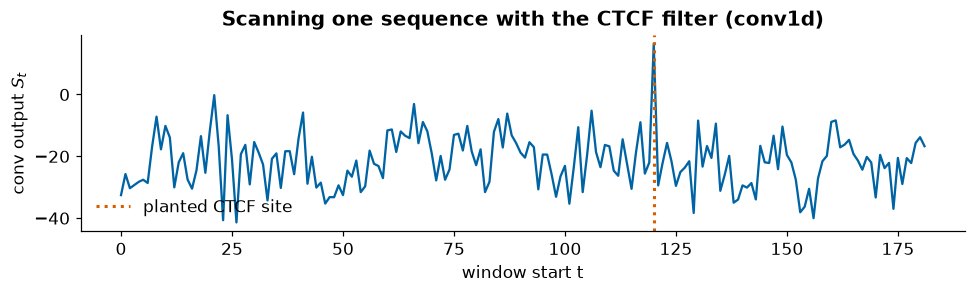

In [9]:
r4 = np.random.default_rng(4)
s_scan = _plant(random_dna(r4, 1, SEQ_L)[0], sample_from_pwm(thA, r4, 1)[0], 120)
sc = nn.functional.conv1d(torch.tensor(onehot([s_scan])).transpose(1, 2), torch.tensor(KA.T[None], dtype=torch.float32))[0, 0]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(sc.numpy(), color=PALETTE[0]); ax.axvline(120, color=PALETTE[5], ls=":", lw=2, label="planted CTCF site")
ax.set(xlabel="window start t", ylabel="conv output $S_t$", title="Scanning one sequence with the CTCF filter (conv1d)")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

Model inputs are float32 tensors of shape $n\times L\times 4$; the models transpose to $n\times 4\times L$ (channels first) for `Conv1d`. No other preprocessing is needed.

In [10]:
X1, X2 = onehot(s1), onehot(s2)
a1, b1 = N1[0], N1[0] + N1[1]
a2, b2 = N2[0], N2[0] + N2[1]
X1tr, y1tr = X1[:a1], y1[:a1]
if RC_AUG:   # reverse-complement augmentation: same label, flipped along both axes
    X1tr, y1tr = np.concatenate([X1tr, X1tr[:, ::-1, ::-1].copy()]), np.concatenate([y1tr, y1tr])
print("task 1 train", X1tr.shape, " val", X1[a1:b1].shape, " test", X1[b1:].shape)
print("task 2 train", X2[:a2].shape, " val", X2[a2:b2].shape, " test", X2[b2:].shape)

task 1 train (4000, 200, 4)  val (1000, 200, 4)  test (2000, 200, 4)
task 2 train (8000, 200, 4)  val (2000, 200, 4)  test (2000, 200, 4)


## 4. Models

- **Pooled CNN** (DeepBind-style): `Conv1d(4 → K, width 19)` → ReLU → **global max pool over positions** → linear. Parameters $(19\cdot 4+1)K + K + 1$: 1,249 for $K=16$ (task 1) and 2,497 for $K=32$ (task 2). Max pooling finds a motif anywhere — and forgets where it was.
- **CNN + BiLSTM** (DanQ-style): 32 filters of width 19 → ReLU → max pool (size 5) → bidirectional LSTM ($d_h=32$ per direction) → max over positions → linear. The recurrence carries order information along the sequence.

In [11]:
def pooled_cnn(K=16, F=19):
    class PooledCNN(nn.Module):
        """conv -> ReLU -> global max pool over positions -> linear (DeepBind-style)."""
        def __init__(self):
            super().__init__()
            self.conv = nn.Conv1d(4, K, F)
            self.fc = nn.Linear(K, 1)

        def forward(self, x):                       # x: batch x L x 4
            h = torch.relu(self.conv(x.transpose(1, 2)))
            return self.fc(h.amax(2)).squeeze(1)
    return PooledCNN()

def cnn_bilstm(K=32, F=19, pool=5, dh=32, cell=RNN_CELL):
    class CNNBiRNN(nn.Module):
        """conv -> ReLU -> max pool (size 5) -> BiLSTM (or BiGRU) -> max over positions -> linear (DanQ-style)."""
        def __init__(self):
            super().__init__()
            self.conv = nn.Conv1d(4, K, F)
            self.pool = nn.MaxPool1d(pool)
            self.rnn = getattr(nn, cell)(K, dh, batch_first=True, bidirectional=True)
            self.fc = nn.Linear(2 * dh, 1)

        def forward(self, x):
            h = self.pool(torch.relu(self.conv(x.transpose(1, 2)))).transpose(1, 2)   # batch x 36 x K
            o, _ = self.rnn(h)
            return self.fc(o.amax(1)).squeeze(1)
    return CNNBiRNN()

def deep_cnn(K=32, F=19):
    """For 'Try it yourself': a deeper CNN whose receptive field (≈ 90 bp) covers A + gap + B."""
    class DeepCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Conv1d(4, K, F), nn.ReLU(), nn.MaxPool1d(5),
                                     nn.Conv1d(K, K, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
                                     nn.Conv1d(K, K, 5, padding=2), nn.ReLU())
            self.fc = nn.Linear(K, 1)

        def forward(self, x):
            return self.fc(self.net(x.transpose(1, 2)).amax(2)).squeeze(1)
    return DeepCNN()

n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"pooled CNN, K = 16 (task 1): {n_params(pooled_cnn()):,} parameters  (formula {(19 * 4 + 1) * 16 + 16 + 1:,})")
print(f"pooled CNN, K = 32 (task 2): {n_params(pooled_cnn(K=32)):,} parameters")
print(f"CNN + Bi{RNN_CELL} (task 2):    {n_params(cnn_bilstm()):,} parameters")
print(f"deeper CNN (try it):        {n_params(deep_cnn()):,} parameters")
print("recurrent cells with d_in = 4, d_h = 32 (PyTorch has two bias vectors, b_ih and b_hh):",
      {k: n_params(M(4, 32)) for k, M in [("RNN", nn.RNN), ("GRU", nn.GRU), ("LSTM", nn.LSTM)]})

pooled CNN, K = 16 (task 1): 1,249 parameters  (formula 1,249)
pooled CNN, K = 32 (task 2): 2,497 parameters
CNN + BiLSTM (task 2):    19,425 parameters
deeper CNN (try it):        12,801 parameters
recurrent cells with d_in = 4, d_h = 32 (PyTorch has two bias vectors, b_ih and b_hh): {'RNN': 1216, 'GRU': 3648, 'LSTM': 4864}


## 5. Training

Same recipe for every model (as in the lecture): binary cross-entropy on the logit, Adam ($\eta = 3\times10^{-3}$), mini-batches of 64, gradient-norm clipping at 5, and the epoch with the best **validation ROC AUC** is kept. The test set is used once at the end.

In [12]:
def train(m, Xtr, ytr, Xva, yva, epochs, lr=3e-3, bs=64):
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    Xtr, ytr, Xva = torch.tensor(Xtr), torch.tensor(ytr).float(), torch.tensor(Xva)
    best, state, hist = -1, None, []
    for _ in range(epochs):
        m.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            loss = nn.functional.binary_cross_entropy_with_logits(m(Xtr[idx]), ytr[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 5.0)   # guards against exploding gradients
            opt.step()
        m.eval()
        with torch.no_grad():
            a = float(roc_auc_score(yva, m(Xva).numpy()))
        hist.append(a)
        if a > best:
            best, state = a, {k: v.clone() for k, v in m.state_dict().items()}
    m.load_state_dict(state)
    return m, hist

def predict(m, X):
    m.eval()
    with torch.no_grad():
        return m(torch.tensor(X)).numpy()

**Task 1** — the pooled CNN, plus two baselines: the L03 PWM scan with the *true* CTCF matrix (an oracle that knows the motif), and L2-regularized logistic regression on the flattened one-hot sequence ($200\cdot4+1 = 801$ parameters, one weight per base per position).

In [13]:
def best_window(X, theta, q=np.full(4, 0.25), both=BOTH_STRANDS):
    """L03 PWM scan: best log-likelihood-ratio window score per sequence (one-hot input); optionally both strands."""
    K, W = np.log(theta / q[None]), len(theta)
    win = np.lib.stride_tricks.sliding_window_view(X, (W, 4), axis=(1, 2))[:, :, 0]  # n x (L-W+1) x W x 4
    s = (win * K).sum((2, 3)).max(1)
    return np.maximum(s, (win * K[::-1, ::-1]).sum((2, 3)).max(1)) if both else s

torch.manual_seed(0)
t0 = time.time()
cnn1, hist1 = train(pooled_cnn(), X1tr, y1tr, X1[a1:b1], y1[a1:b1], EP1)
t_cnn1 = time.time() - t0
p_cnn1 = predict(cnn1, X1[b1:])
lr1 = LogisticRegression(C=0.1, max_iter=3000).fit(X1[:a1].reshape(a1, -1), y1[:a1])
p_lr1 = lr1.decision_function(X1[b1:].reshape(len(X1) - b1, -1))
p_pwm1 = best_window(X1[b1:], thA)
print(f"CNN trained in {t_cnn1:.0f} s; validation AUC by epoch:", np.round(hist1, 3))

CNN trained in 7 s; validation AUC by epoch: [0.97  0.987 0.989 0.99  0.991 0.992 0.992 0.992 0.992 0.993]


**Task 2** — the pooled CNN (32 filters) and the CNN + BiLSTM, each from `torch.manual_seed(0)`, 15 epochs.

In [14]:
MODELS2 = {"pooled CNN": lambda: pooled_cnn(K=32), f"CNN + Bi{RNN_CELL}": cnn_bilstm}
# MODELS2["deeper CNN"] = deep_cnn          # Try it yourself
res2 = {}
for name, make in MODELS2.items():
    torch.manual_seed(0)
    t0 = time.time()
    m, hist = train(make(), X2[:a2], y2[:a2], X2[a2:b2], y2[a2:b2], EP2)
    p = predict(m, X2[b2:])
    res2[name] = dict(model=m, hist=hist, p=p, seconds=time.time() - t0)
    print(f"{name}: {res2[name]['seconds']:.0f} s, best validation AUC {max(hist):.3f} (epoch {int(np.argmax(hist)) + 1})")

pooled CNN: 14 s, best validation AUC 0.514 (epoch 9)


CNN + BiLSTM: 28 s, best validation AUC 0.995 (epoch 7)


## 6. Evaluation on the test sets

In [15]:
yt1 = y1[b1:]
print(f"Task 1 test set ({len(yt1):,} sequences)")
print(f"{'model':45s} {'params':>7s} {'ROC AUC':>8s} {'accuracy':>9s}")
print(f"{'PWM scan with the true CTCF matrix (L03)':45s} {'0':>7s} {roc_auc_score(yt1, p_pwm1):8.3f} {'—':>9s}")
print(f"{'logistic regression on flattened one-hot':45s} {X1[0].size + 1:7,d} {roc_auc_score(yt1, p_lr1):8.3f} "
      f"{100 * accuracy_score(yt1, p_lr1 > 0):8.2f}%")
print(f"{'1D CNN: 16 filters x 19 bp, global max pool':45s} {n_params(cnn1):7,d} {roc_auc_score(yt1, p_cnn1):8.3f} "
      f"{100 * accuracy_score(yt1, p_cnn1 > 0):8.2f}%")

yt2, kt2 = y2[b2:], kind2[b2:]
print(f"\nTask 2 test set ({len(yt2):,} sequences)   accuracy by kind: A→B near (y=1) | B→A | A→B far")
for name, r in res2.items():
    acc_kind = [np.mean((r["p"][kt2 == k] > 0) == (k == 0)) for k in range(3)]
    print(f"{name:18s} {n_params(r['model']):7,d} params   AUC {roc_auc_score(yt2, r['p']):.3f}   "
          f"accuracy {accuracy_score(yt2, r['p'] > 0):.1%}   " + " | ".join(f"{a:.1%}" for a in acc_kind))

Task 1 test set (2,000 sequences)
model                                          params  ROC AUC  accuracy
PWM scan with the true CTCF matrix (L03)            0    0.997         —
logistic regression on flattened one-hot          801    0.578    55.70%
1D CNN: 16 filters x 19 bp, global max pool     1,249    0.994    96.25%

Task 2 test set (2,000 sequences)   accuracy by kind: A→B near (y=1) | B→A | A→B far
pooled CNN           2,497 params   AUC 0.494   accuracy 48.2%   71.7% | 24.7% | 27.4%
CNN + BiLSTM        19,425 params   AUC 0.992   accuracy 95.5%   94.8% | 95.4% | 97.0%


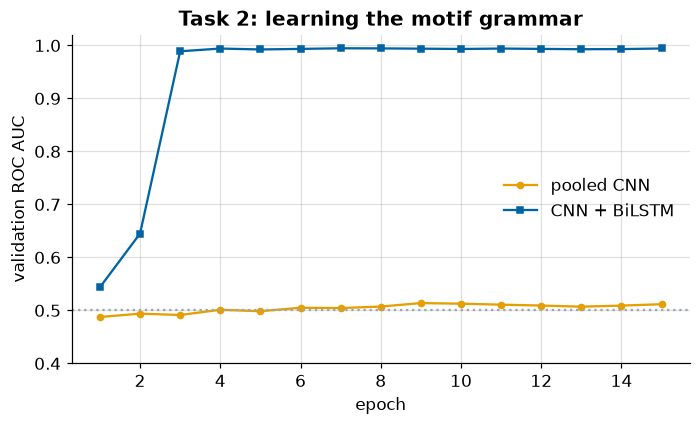

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for (name, r), c, mk in zip(res2.items(), [PALETTE[1], PALETTE[0], PALETTE[2]], "osd"):
    ax.plot(np.arange(1, len(r["hist"]) + 1), r["hist"], "-" + mk, ms=4, color=c, label=name)
ax.axhline(0.5, color="#9AA5B1", ls=":")
ax.set(xlabel="epoch", ylabel="validation ROC AUC", ylim=(0.4, 1.02), title="Task 2: learning the motif grammar")
ax.grid(alpha=0.4); ax.legend(loc="center right"); plt.tight_layout(); plt.show()

**Reading the results.** In task 1 the CNN nearly matches the oracle PWM scan without being told the motif, while logistic regression on the flattened sequence is barely above chance: it must learn the site separately at each of the 182 possible start positions from 4,000 examples. Weight sharing across positions is the right prior (same story as MLP vs CNN on shifted blood cells in L09).

In task 2 the pooled CNN stays at chance (AUC ≈ 0.5): after global max pooling it only knows *that* CTCF and FOXA1 are present — true for every sequence — not their order or distance. The BiLSTM reads the pooled feature sequence in both directions and learns the rule. Its validation AUC jumps after a couple of epochs, a typical sign of a model discovering a combinatorial feature.

**Comparison with the slides.** Task 1 reproduces the deck exactly (CNN 1,249 params, AUC 0.994, 96.25% accuracy — shown as 96.3% on the slide; PWM scan 0.997; logistic 0.578). In task 2 this run gives pooled CNN AUC 0.494 (deck 0.496) and CNN + BiLSTM AUC 0.992 with about 95.5% accuracy (deck 0.992 / 96.4%). The data, seeds and parameter counts are identical; the small difference comes from floating-point operation order in multi-threaded CPU kernels (it differs between machines, PyTorch builds and even runs), which changes the trained weights slightly and which epoch is selected. The PWM = conv1d check likewise gives a maximum difference of order 1e-05 here versus 6e-06 on the slides — both are float32 rounding.

## 7. Visualization: what did the networks learn?

### 7a. The task-1 filter is the CTCF motif
We pick the filter whose maximum activation best separates positives from negatives, collect the fresh test windows that activate it to more than 50% of its maximum, and turn their base counts into a logo (the DeepBind / DanQ recipe). `align` finds the best Pearson correlation with the JASPAR matrix over shifts and both strands.

filter 6 of 16: activation gap 3.73; logo from 926 windows (99.0% from positive sequences)
correlation with JASPAR MA0139.1: r = 0.999 after a 1-bp shift (strand +)
5 of 16 filters are informative (gap > 1); 5 of them have a CTCF logo (r > 0.9)


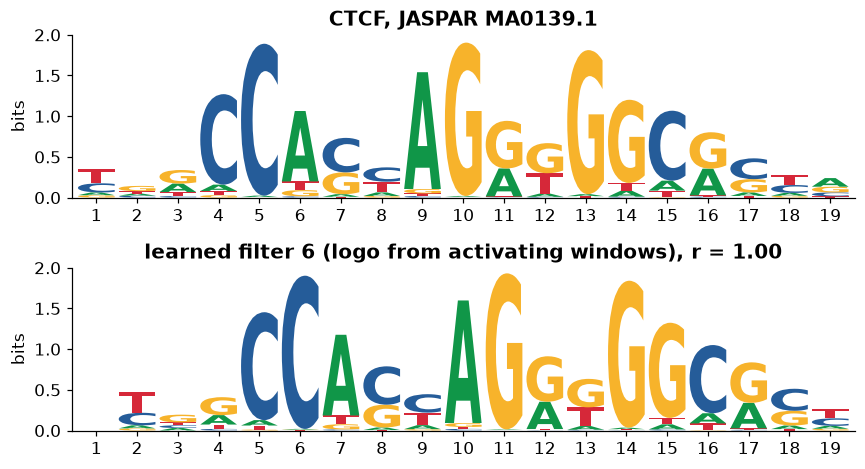

In [17]:
def align(th, ref, max_off=6):
    """Best Pearson correlation between two PWMs over shifts and both strands: (r, offset, strand)."""
    F, best = len(th), (-2.0, 0, "+")
    for strand, r in [("+", ref), ("−", ref[::-1, ::-1])]:
        for off in range(-max_off, max_off + 1):
            a0, b0 = max(0, off), max(0, -off)
            n = min(F - a0, len(r) - b0)
            if n >= 10:
                c = float(np.corrcoef(th[a0:a0 + n].ravel(), r[b0:b0 + n].ravel())[0, 1])
                if c > best[0]:
                    best = (c, off, strand)
    return best

def filter_logo(act, X, j, F):
    ii, tt = np.where(act[:, j] > 0.5 * act[:, j].max())
    counts = sum(X[i, t:t + F] for i, t in zip(ii, tt))
    return pwm_from_counts(counts, 0.5), ii

s7, y7, _ = task1_data(np.random.default_rng(7), 2000)
X7 = onehot(s7)
with torch.no_grad():
    act = torch.relu(cnn1.conv(torch.tensor(X7).transpose(1, 2))).numpy()     # n x K x (L-F+1)
mx = act.max(2)
sep = mx[y7 == 1].mean(0) - mx[y7 == 0].mean(0)
k = int(np.argmax(sep))
F = cnn1.conv.kernel_size[0]
theta_k, ii = filter_logo(act, X7, k, F)
corr, off, strand = align(theta_k, thA)
if strand == "−":
    theta_k = theta_k[::-1, ::-1]
n_inf = int((sep > 1).sum())
n_good = sum(align(filter_logo(act, X7, j, F)[0], thA)[0] > 0.9 for j in range(act.shape[1]) if sep[j] > 1)
print(f"filter {k + 1} of {act.shape[1]}: activation gap {sep[k]:.2f}; logo from {len(ii):,} windows "
      f"({y7[ii].mean():.1%} from positive sequences)")
print(f"correlation with JASPAR MA0139.1: r = {corr:.3f} after a {abs(off)}-bp shift (strand {strand})")
print(f"{n_inf} of {act.shape[1]} filters are informative (gap > 1); {n_good} of them have a CTCF logo (r > 0.9)")

fig, axs = plt.subplots(2, 1, figsize=(8, 4.4))
plot_logo(axs[0], thA); axs[0].set_title(f"{nameA}, JASPAR MA0139.1")
plot_logo(axs[1], theta_k); axs[1].set_title(f"learned filter {k + 1} (logo from activating windows), r = {corr:.2f}")
plt.tight_layout(); plt.show()

### 7b. In-silico mutagenesis
Change every base in a 40-bp window around a planted CTCF consensus site to each alternative and record the change in the CNN's logit (a DeepBind-style *mutation map*). This is how sequence models are used to score non-coding variants.

reference logit 12.3; largest drop -4.9 (inside the site); largest |Δ| outside the site 0.43


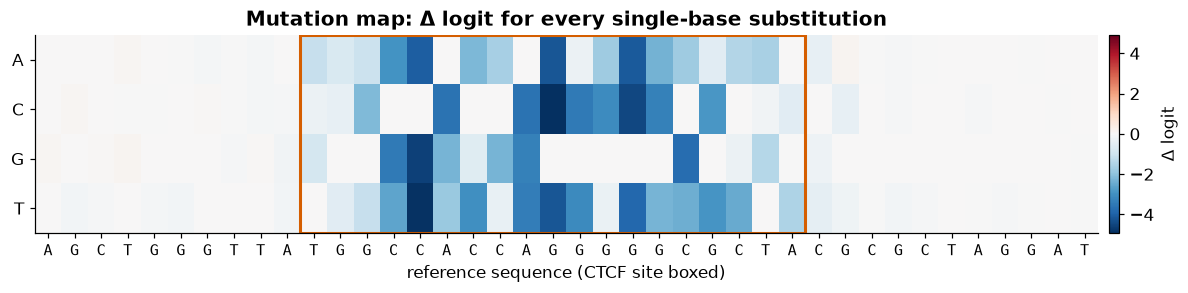

In [18]:
r21 = np.random.default_rng(21)
p0 = 90
s_mut = _plant(random_dna(r21, 1, SEQ_L, GC)[0], sA, p0)
lo, hi = p0 - 10, p0 + WA + 11
muts = [s_mut[:t] + b + s_mut[t + 1:] for t in range(lo, hi) for b in BASES]
with torch.no_grad():
    z = cnn1(torch.tensor(onehot([s_mut] + muts))).numpy()
D = (z[1:] - z[0]).reshape(hi - lo, 4).T                                   # 4 x window
print(f"reference logit {z[0]:.1f}; largest drop {D.min():.1f} (inside the site); "
      f"largest |Δ| outside the site {np.abs(np.delete(D, np.s_[10:10 + WA], axis=1)).max():.2f}")

fig, ax = plt.subplots(figsize=(11, 2.8))
v = np.abs(D).max()
im = ax.imshow(D, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
ax.set_yticks(range(4), list(BASES))
ax.set_xticks(range(hi - lo), list(s_mut[lo:hi]), fontsize=10, family="monospace")
ax.add_patch(plt.Rectangle((10 - 0.5, -0.5), WA, 4, fill=False, ec=PALETTE[5], lw=2))
ax.set(xlabel="reference sequence (CTCF site boxed)", title="Mutation map: Δ logit for every single-base substitution")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01, label="Δ logit"); plt.tight_layout(); plt.show()

### 7c. Saliency for the CNN + BiLSTM (task 2)
Gradient × input, $\sum_a X_{t,a}\,\partial z/\partial X_{t,a}$, for a positive (A → B) and a negative (B → A) sequence. Among the first 40 correctly classified sequences of each kind we show the one whose attribution is most concentrated on the two sites, and print the median concentration too, so you can see these are clean rather than random examples.

A → B (y = 1): share of |attribution| on the two sites 76.6% (median over 40 candidates 53.5%; sites cover 15.5% of the sequence)
B → A (y = 0): share of |attribution| on the two sites 67.8% (median over 40 candidates 42.3%; sites cover 15.5% of the sequence)


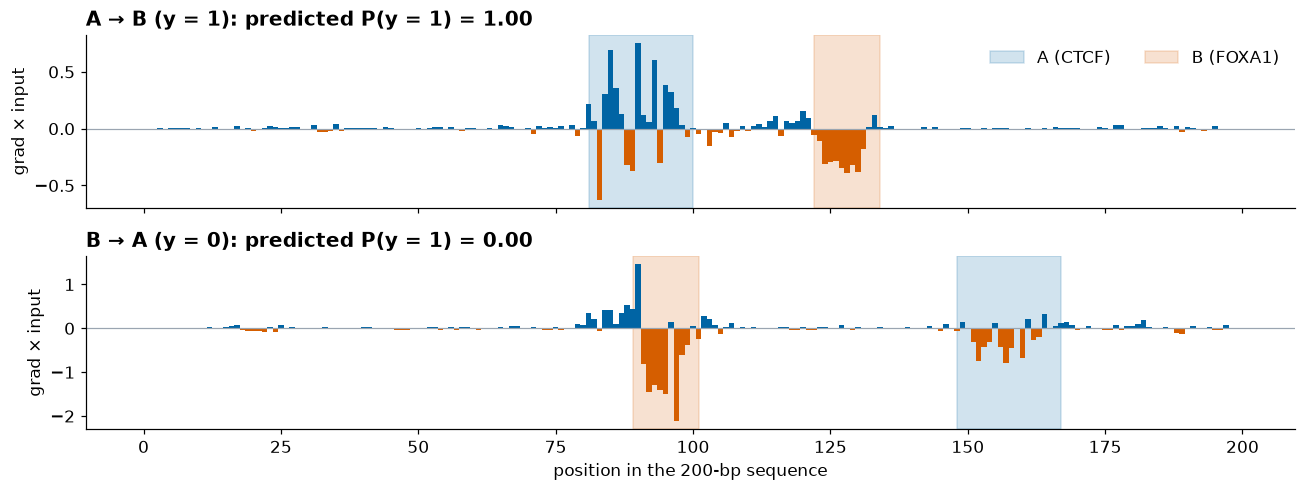

In [19]:
m2 = res2[f"CNN + Bi{RNN_CELL}"]["model"]
s11, y11, kind11, pos11 = task2_data(np.random.default_rng(11), 400)
X11 = onehot(s11)
p11 = predict(m2, X11)
x = torch.tensor(X11, requires_grad=True)
m2.train()       # cuDNN RNN backward needs train mode; there is no dropout or BatchNorm, so outputs are unchanged
m2(x).sum().backward()
m2.eval()
GI = (x.grad * x).sum(2).detach().numpy()
sal = []
for kk in (0, 1):
    cand = np.where((kind11 == kk) & ((p11 > 0) == (kk == 0)))[0][:40]
    frac = []
    for i in cand:
        mask = np.zeros(SEQ_L, bool)
        mask[pos11[i][0]:pos11[i][0] + WA] = True
        mask[pos11[i][1]:pos11[i][1] + WB] = True
        frac.append(np.abs(GI[i][mask]).sum() / np.abs(GI[i]).sum())
    i = int(cand[int(np.argmax(frac))])
    sal.append(dict(i=i, kind=kk, frac=max(frac), med=np.median(frac)))
    print(f"{'A → B (y = 1)' if kk == 0 else 'B → A (y = 0)'}: share of |attribution| on the two sites "
          f"{max(frac):.1%} (median over 40 candidates {np.median(frac):.1%}; sites cover {(WA + WB) / SEQ_L:.1%} of the sequence)")

fig, axs = plt.subplots(2, 1, figsize=(12, 4.6), sharex=True)
for ax, d in zip(axs, sal):
    i = d["i"]; g = GI[i]
    ax.axvspan(pos11[i][0], pos11[i][0] + WA, color=COL_A, alpha=0.18, label=f"A ({nameA})")
    ax.axvspan(pos11[i][1], pos11[i][1] + WB, color=COL_B, alpha=0.18, label=f"B ({nameB})")
    ax.bar(np.arange(SEQ_L), g, width=1.0, color=np.where(g >= 0, PALETTE[0], PALETTE[5]))
    ax.axhline(0, color="#9AA5B1", lw=0.8)
    lab = "A → B (y = 1)" if d["kind"] == 0 else "B → A (y = 0)"
    ax.set_title(f"{lab}: predicted P(y = 1) = {1 / (1 + np.exp(-p11[i])):.2f}", loc="left")
    ax.set_ylabel("grad × input")
axs[0].legend(loc="upper right", ncol=2)
axs[1].set_xlabel("position in the 200-bp sequence"); plt.tight_layout(); plt.show()

## 8. Vanishing gradients: plain RNN vs LSTM

For a scalar RNN, $\partial h_L/\partial h_0$ contains a product of $L$ factors $w\,\tanh'(\cdot)$, so it behaves like $|w|^L$: it vanishes for $|w|<1$ and explodes for $|w|>1$ (left). On the right, the lecture's experiment: the influence of the **first base** on the state after $T$ steps, $\|\partial(\mathbf u^\top\mathbf h_T)/\partial\mathbf x_1\|$, for random DNA at initialization ($d_h = 32$, geometric mean over 20 random networks and sequences). The tanh RNN has $\mathbf W_{hh} = \rho\,\mathbf Q$ with $\mathbf Q$ random orthogonal; the LSTM uses PyTorch's default initialization with forget-gate bias $b_f = 1$ or $3$ ($f_t\approx\sigma(b_f) = 0.73$ or $0.95$).

RNN, ρ = 0.8    influence after 60 steps relative to T = 0: 1.1e-07
RNN, ρ = 1.0    influence after 60 steps relative to T = 0: 4.8e-03
RNN, ρ = 1.2    influence after 60 steps relative to T = 0: 4.7e-01
LSTM, b_f = 1   influence after 60 steps relative to T = 0: 4.8e-05
LSTM, b_f = 3   influence after 60 steps relative to T = 0: 4.9e-01


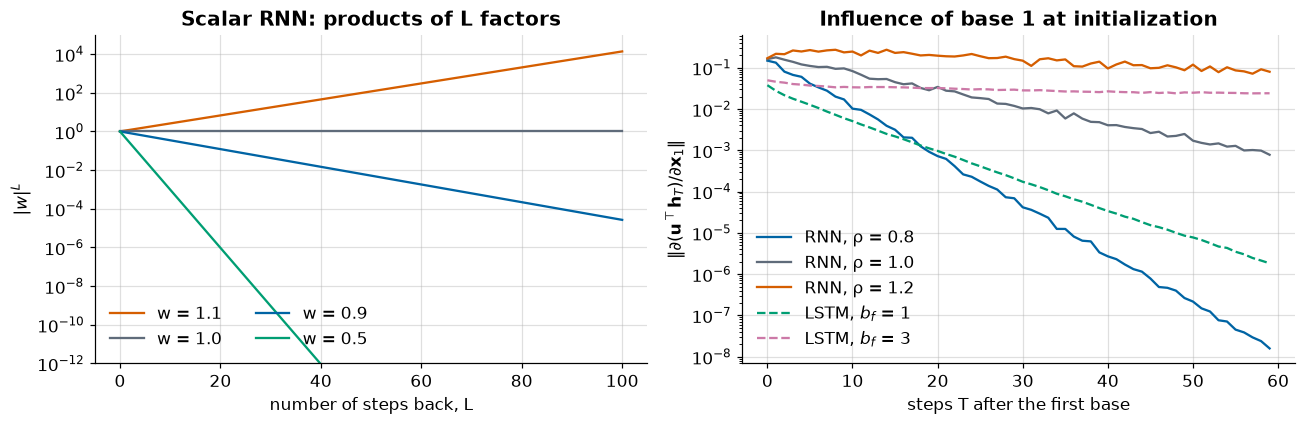

In [20]:
def influence(T=60, dh=32, reps=20):
    torch.manual_seed(0)
    rg = np.random.default_rng(0)
    res = {}
    configs = [(f"RNN, ρ = {r}", "rnn", r) for r in (0.8, 1.0, 1.2)] + [(f"LSTM, b_f = {b}", "lstm", b) for b in (1, 3)]
    for lab, kind, rho in configs:
        curves = []
        for rep in range(reps):
            if kind == "rnn":
                m = nn.RNN(4, dh, batch_first=True)
                q, _ = torch.linalg.qr(torch.randn(dh, dh))
                with torch.no_grad():
                    m.weight_hh_l0.copy_(rho * q)
            else:
                m = nn.LSTM(4, dh, batch_first=True)
                with torch.no_grad():
                    m.bias_ih_l0[dh:2 * dh] = float(rho)   # forget-gate bias (PyTorch gate order i, f, g, o)
                    m.bias_hh_l0[dh:2 * dh] = 0.0
            x = torch.tensor(np.eye(4, dtype=np.float32)[rg.integers(0, 4, T)][None], requires_grad=True)
            o, _ = m(x)
            u = torch.randn(dh); u /= u.norm()
            g = []
            for t in range(T):
                gr, = torch.autograd.grad((o[0, t] * u).sum(), x, retain_graph=True)
                g.append(float(gr[0, 0].norm()))
            curves.append(g)
        res[lab] = np.exp(np.log(np.array(curves) + 1e-30).mean(0))   # geometric mean over reps
    return res

infl = influence()
for lab, g in infl.items():
    print(f"{lab:15s} influence after 60 steps relative to T = 0: {g[-1] / g[0]:.1e}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
t = np.arange(0, 101)
for w, c in [(1.1, PALETTE[5]), (1.0, "#5F6B7A"), (0.9, PALETTE[0]), (0.5, PALETTE[2])]:
    axs[0].semilogy(t, w ** t, color=c, label=f"w = {w}")
axs[0].set(xlabel="number of steps back, L", ylabel=r"$|w|^L$", ylim=(1e-12, 1e5), title="Scalar RNN: products of L factors")
axs[0].legend(loc="lower left", ncol=2)
for (lab, g), c in zip(infl.items(), [PALETTE[0], "#5F6B7A", PALETTE[5], PALETTE[2], PALETTE[3]]):
    axs[1].semilogy(g, color=c, ls="--" if "LSTM" in lab else "-", label=lab.replace("b_f", "$b_f$"))
axs[1].set(xlabel="steps T after the first base", ylabel=r"$\|\partial(\mathbf{u}^\top\mathbf{h}_T)/\partial\mathbf{x}_1\|$",
           title="Influence of base 1 at initialization")
axs[1].legend(loc="lower left")
for ax in axs:
    ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

A plain RNN needs $\rho$ tuned near 1 (the "edge of chaos"): below 1 the influence of early bases dies exponentially; above 1 the linearized dynamics would explode, and the tanh saturation keeps the influence roughly constant but makes the state chaotic and training unstable. The LSTM with the default-like $b_f = 1$ forgets almost as fast as the $\rho = 0.8$ RNN. The LSTM's cell state is updated only by $\times\,\mathbf f_t$ and $+$, with no weight matrix; with a large forget-gate bias ($f_t\approx 0.95$) information from base 1 survives far longer. Gradient clipping (used in `train`) handles explosions; gated cells handle vanishing.

## 9. Biological interpretation

- A CNN trained only on "bound / not bound" labels **rediscovered the CTCF motif** (filter logo r ≈ 1.00 vs JASPAR). This is how DeepBind-style models are used for motif discovery on real ChIP-seq data — but on real data the learned logos are messier (co-factors, GC and repeat biases), so compare them with JASPAR using a tool such as TomTom before naming them.
- The mutation map shows which bases matter: substitutions at the high-information core of the site lower the score; bases outside the site barely matter. On real data this is how a model predicts the effect of a regulatory variant — a hypothesis to test, not a diagnosis.
- Detecting motifs is not enough when **arrangement** matters: cooperative TF binding and enhancer "grammar" depend on order, orientation and spacing. A pooled CNN is blind to them; a recurrent (or attention, L12) layer on top of the motif scanners can learn them. The saliency maps confirm the BiLSTM bases its decision on the two sites — the same evidence in both sequences, but in a different order.
- Caveats: the data are simulated with a uniform background, sites on one strand and a hard-coded rule; real regulatory DNA has GC and repeat structure, many weak sites, and soft, context-dependent grammars.

## 10. Try it yourself

1. **Plant sites on either strand: does RC augmentation help?** Set `BOTH_STRANDS = True` in the first code cell and rerun. Compare the CNN's test AUC with `RC_AUG = False` and `RC_AUG = True`. (The PWM scan then scans both strands.) Look at the learned filters: do you get separate forward and reverse-complement detectors?
2. **Swap the BiLSTM for a GRU or a deeper CNN.** Set `RNN_CELL = "GRU"` (fewer parameters — how many?), or uncomment `MODELS2["deeper CNN"] = deep_cnn` in the task-2 training cell. Can a CNN without recurrence learn the grammar once its receptive field covers both sites and the gap?
3. **Use a 60% GC background.** Set `GC = 0.6`. The CTCF motif is GC-rich: what happens to the PWM scan with a uniform background $q$ (try `best_window(X1[b1:], thA, q=np.array([0.2, 0.3, 0.3, 0.2]))`) and to the CNN?
4. In task 2, why would reverse-complement augmentation be **wrong** with the label as defined ("A upstream of B" on the forward strand)? How would you redefine the label so that it is strand-symmetric?
5. *(CS284A)* Change the forget-gate bias in `influence()` to 0 and to 5, and add a GRU. Relate the slopes of the curves to $\log\sigma(b_f)$.